# 01, Explore the B11 catalog

Per `plan.md` §10 / §11 step 1. Loads `Data/J_AJ_141_23/table7.dat`,
renders diameter / Vexp / axial-ratio histograms, and breaks the 1046
holes down by hole type (1/2/3) per galaxy. Use this to confirm §2.4
decisions about the type-1 split before locking the LOGO run.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hishells.catalog import load_catalog, LOGO_GALAXIES_19

In [2]:
REPO = Path('..').resolve()
cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
holes, gals = cat.holes, cat.galaxies
print(f'{len(holes)} holes across {holes["galaxy_id"].nunique()} galaxies')
print(f'{len(LOGO_GALAXIES_19)} galaxies reachable for LOGO ({set(holes["galaxy_id"]) - set(LOGO_GALAXIES_19)} excluded)')
holes.head()

1046 holes across 20 galaxies
19 galaxies reachable for LOGO ({'IC_2574'} excluded)


,name_b11,galaxy_id,hole_idx,ra_deg,dec_deg,vel_helio_kms,hole_type,diameter_pc,vexp_kms,pa_deg,axial_ratio,gc_radius_kpc,n_HI_raw,t_kin_myr,log_E_J43,log_MHI_1e4Msun,distance_mpc,diameter_arcsec,sigma_gas_kms
0,NGC 628,NGC_628,1,24.083750,15.729222,645.0,1,520.0,7.0,109.0,0.7,13.1,-1.1,36.0,1.2,1.2,7.3,14.692849,10.0
1,NGC 628,NGC_628,2,24.084167,15.752139,650.0,1,849.0,7.0,0.0,1.0,11.8,-1.0,59.0,2.0,1.9,7.3,23.988902,10.0
2,NGC 628,NGC_628,3,24.097500,15.728778,639.0,1,575.0,7.0,149.0,0.5,11.7,-0.9,40.0,1.6,1.6,7.3,16.246901,10.0
3,NGC 628,NGC_628,4,24.100000,15.741694,639.0,2,546.0,10.0,126.0,0.8,10.5,-0.7,27.0,1.9,1.6,7.3,15.427492,10.0
4,NGC 628,NGC_628,5,24.100417,15.848778,665.0,2,459.0,7.0,0.0,0.9,12.4,-0.8,32.0,1.4,1.3,7.3,12.969265,10.0


## Hole-type breakdown

Type 1 = stalled (no measurable Vexp), 2 = one-sided expansion,
3 = two-sided expansion (textbook ellipse). Per §2.4 the v1 default
trains on types {2,3} only, use the bar chart below to confirm that
still leaves enough positives per galaxy.

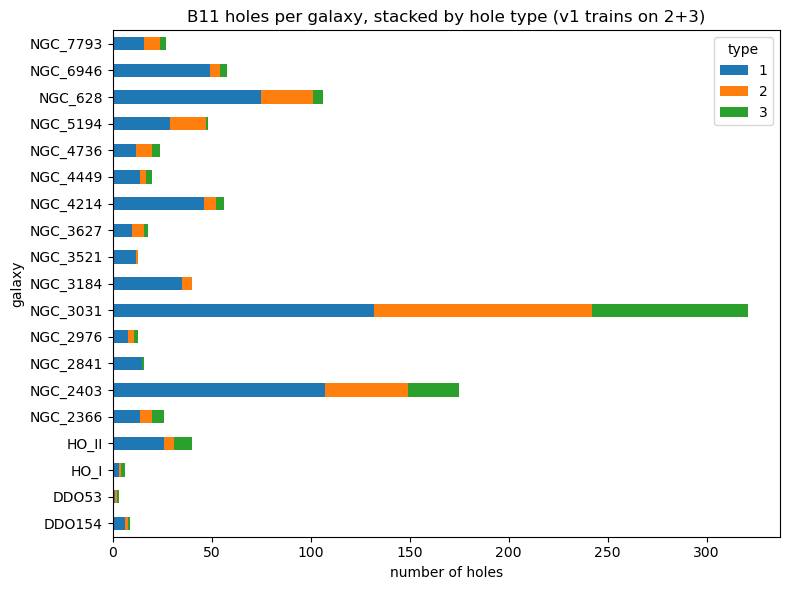

In [3]:
by_type = holes.groupby(['galaxy_id', 'hole_type']).size().unstack(fill_value=0)
by_type = by_type.reindex(LOGO_GALAXIES_19)
ax = by_type.plot.barh(stacked=True, figsize=(8, 6))
ax.set_xlabel('number of holes')
ax.set_ylabel('galaxy')
ax.set_title('B11 holes per galaxy, stacked by hole type (v1 trains on 2+3)')
ax.legend(title='type')
plt.tight_layout()

In [4]:
summary = by_type.copy()
summary['total'] = summary.sum(axis=1)
summary['types_2_3'] = summary.get(2, 0) + summary.get(3, 0)
summary['frac_2_3'] = summary['types_2_3'] / summary['total']
summary.style.format({'frac_2_3': '{:.0%}'})

hole_type,1,2,3,total,types_2_3,frac_2_3
galaxy_id,,,,,,
DDO154,6,2,1,9,3,33%
DDO53,1,1,1,3,2,67%
HO_I,3,1,2,6,3,50%
HO_II,26,5,9,40,14,35%
NGC_2366,14,6,6,26,12,46%
NGC_2403,107,42,26,175,68,39%
NGC_2841,15,0,1,16,1,6%
NGC_2976,8,3,2,13,5,38%
NGC_3031,132,110,79,321,189,59%


## Diameter / Vexp / axial-ratio histograms

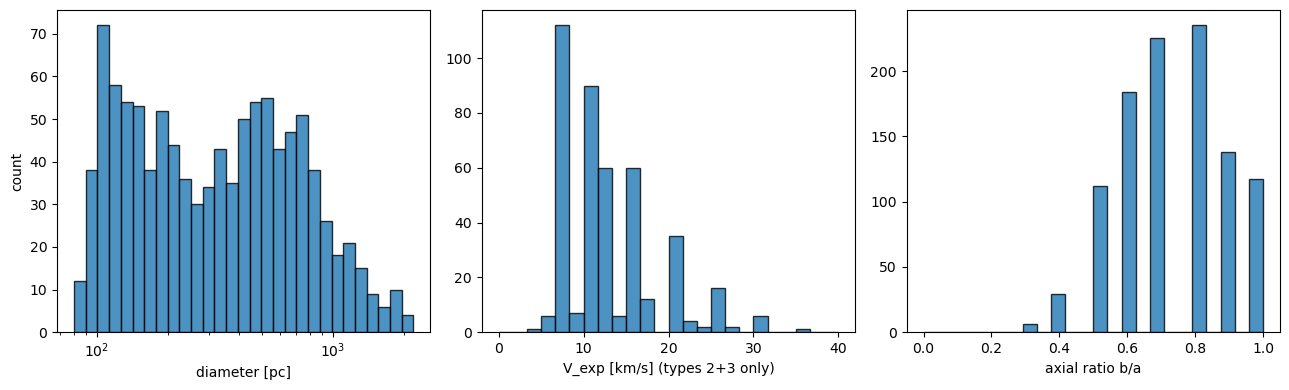

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, label, bins) in zip(
    axes,
    [
        ('diameter_pc', 'diameter [pc]', np.logspace(np.log10(80), np.log10(2200), 30)),
        ('vexp_kms', 'V_exp [km/s] (types 2+3 only)', np.linspace(0, 40, 25)),
        ('axial_ratio', 'axial ratio b/a', np.linspace(0.0, 1.0, 25)),
    ],
):
    sub = holes if col != 'vexp_kms' else holes[holes['hole_type'].isin([2, 3])]
    ax.hist(sub[col].dropna(), bins=bins, color='tab:blue', edgecolor='k', alpha=0.8)
    ax.set_xlabel(label)
    if col == 'diameter_pc':
        ax.set_xscale('log')
axes[0].set_ylabel('count')
fig.tight_layout()

## Galactocentric radius vs hole diameter

B11 §5 reports that 23% of holes lie outside R25 and that shear bounds
hole age (and therefore hole size) in spirals. Use this scatter to
sanity-check the catalog and to bookmark large-radius outliers for
§06_failure_analysis.ipynb.

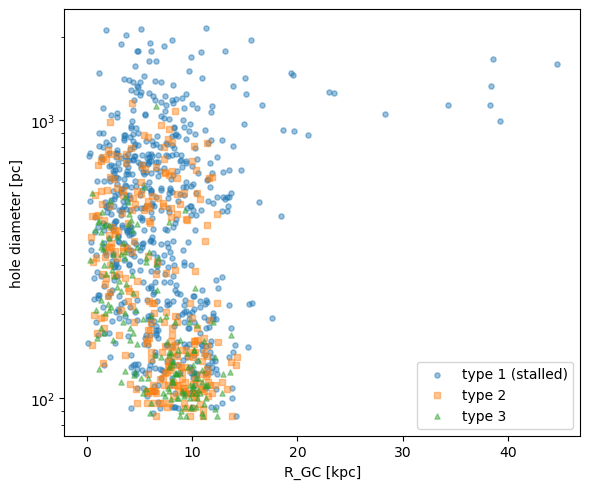

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
for ht, marker, label in [(1, 'o', 'type 1 (stalled)'), (2, 's', 'type 2'), (3, '^', 'type 3')]:
    sub = holes[holes['hole_type'] == ht]
    ax.scatter(sub['gc_radius_kpc'], sub['diameter_pc'], s=14, marker=marker, alpha=0.45, label=label)
ax.set_xlabel('R_GC [kpc]')
ax.set_ylabel('hole diameter [pc]')
ax.set_yscale('log')
ax.legend(loc='best')
fig.tight_layout()

## What this notebook locks

- Confirm that types {2,3} together leave ≥ ~20 holes per galaxy on at
  least 15/19 LOGO folds. If not, revisit §2.4.
- Confirm that diameter range matches `100 pc` to `~2 kpc`. If a galaxy
  has holes outside that range, double-check `Data/J_AJ_141_23/table7.dat`
  alignment in `tests/test_catalog.py`.

---

## Bayesian deep dive

The descriptive plots above answer "what does the catalog look like";
the next five PyMC models answer "what does the *posterior* over the
catalog look like, and which `plan.md` defaults does it ratify or push
back on?" Each model is implemented in
[`hishells.catalog_bayes`](../hishells/catalog_bayes.py) and ties back
to a specific decision in [`plan.md`](../../plan.md):

| # | Model | Likelihood | `plan.md` decision it informs |
|---|---|---|---|
| 1 | Hole-type fractions | Hierarchical Dirichlet–Multinomial with learned concentration `alpha` | §2.4 type-{2,3} filter |
| 2 | Beam-truncated diameter law | TruncatedNormal on `log(diameter_pc)` with non-centered hierarchy | §6 LOGO heterogeneity, §12 normalization |
| 3 | Chevalier-style energy regression | Normal on `log_E_J43` with `Normal(2,1)` priors on size / velocity exponents | §11 step 6 catalog-parsing sanity |
| 4 | Negative-Binomial hole-count rate | NB GLM on `log_sfr`, `log_MHI`, `log(distance)` | §6 anomalous-fold callouts (Pareto-k LOO) |
| 5 | BEST axial-ratio comparison | Student-t per hole type | §2.4 corollary (does type-3 really show a tighter ellipse?) |

Sampler defaults: 4 chains × 2000 draws × 1000 tune, NUTS,
`target_accept = 0.9` (0.95 for the truncated model). Total run time
on CPU is ≈ 4 min cold; subsequent re-runs hit the NetCDF cache under
[`HIShells/results/bayes/`](../results/bayes/) and complete in
under a second.

In [7]:
import warnings
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', UserWarning)

import arviz as az
import pymc as pm

from hishells.catalog_bayes import (
    fit_type_fractions,
    fit_truncated_diameter,
    fit_chevalier,
    fit_count_rate,
    fit_axial_best,
    cached_fit,
    hash_dataframe,
)

print(f'pymc {pm.__version__}, arviz {az.__version__}')

CACHE_DIR = REPO / 'results' / 'bayes'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SEED, DRAWS = 0, 2000

logo_holes = holes[holes['galaxy_id'].isin(LOGO_GALAXIES_19)].reset_index(drop=True)
logo_galaxies = gals[gals['galaxy_id'].isin(LOGO_GALAXIES_19)].reset_index(drop=True)
print(f'fitting on {len(logo_holes)} holes across {logo_galaxies.shape[0]} galaxies')

pymc 5.28.5, arviz 0.23.4
fitting on 1019 holes across 19 galaxies


### Model 1, hierarchical Dirichlet–Multinomial of hole-type fractions

For each galaxy `g` and type `t ∈ {1, 2, 3}`:

\[
\alpha_t \sim \text{HalfNormal}(2),\quad
\boldsymbol{\pi}_g \sim \text{Dirichlet}(\boldsymbol{\alpha}),\quad
\mathbf{n}_g \sim \text{Multinomial}(N_g, \boldsymbol{\pi}_g)
\]

`alpha` is the *learned* population concentration (partial pooling
across galaxies). The deterministic `pi_23 = pi[2] + pi[3]` is the
per-galaxy fraction of holes the v1 default §2.4 filter retains. The
gating question for §2.4 is the **lower bound** of `pi_23` on each
LOGO fold: if it sits below ~0.4 anywhere, training on types {2,3}
will starve that fold of positives.

In [8]:
key1 = hash_dataframe(logo_holes[['galaxy_id', 'hole_type']], DRAWS, SEED, tuple(LOGO_GALAXIES_19))
idata1 = cached_fit(
    CACHE_DIR, 'type_fractions', key1,
    lambda: fit_type_fractions(logo_holes, galaxy_ids=LOGO_GALAXIES_19, draws=DRAWS, seed=SEED),
)
az.summary(idata1, var_names=['alpha']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[1],5.174,1.154,3.124,7.418,0.014,0.012,7192.0,5412.0,1.0
alpha[2],1.937,0.482,1.069,2.835,0.006,0.005,6769.0,6376.0,1.0
alpha[3],1.236,0.319,0.655,1.818,0.004,0.003,5969.0,5976.0,1.0


18/19 galaxies have a 95% lower bound on pi_23 below 0.4


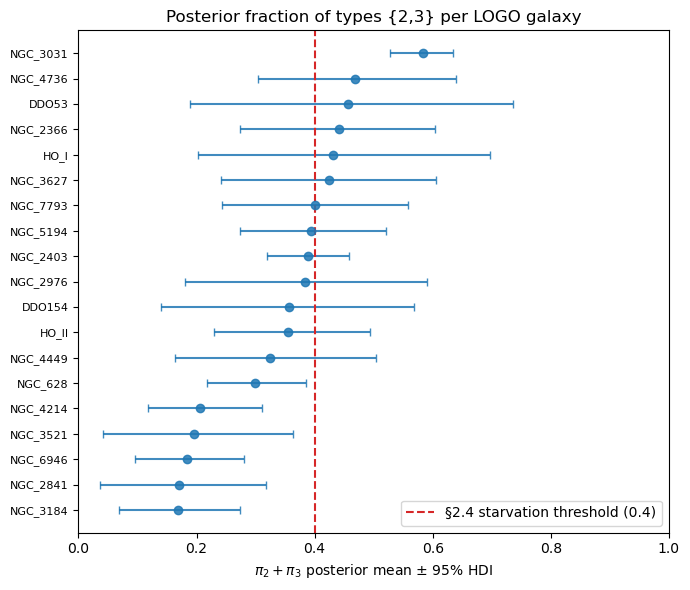

In [9]:
pi23 = az.summary(idata1, var_names=['pi_23'], hdi_prob=0.95)
pi23.index = [str(i).replace('pi_23[', '').rstrip(']') for i in pi23.index]
pi23 = pi23.sort_values('mean')

fig, ax = plt.subplots(figsize=(7, 6))
y = np.arange(len(pi23))
ax.errorbar(
    pi23['mean'], y,
    xerr=[pi23['mean'] - pi23['hdi_2.5%'], pi23['hdi_97.5%'] - pi23['mean']],
    fmt='o', color='tab:blue', ecolor='tab:blue', alpha=0.85, capsize=3,
)
ax.axvline(0.4, color='tab:red', ls='--', label='§2.4 starvation threshold (0.4)')
ax.set_yticks(y)
ax.set_yticklabels(pi23.index, fontsize=8)
ax.set_xlabel(r'$\pi_{2}+\pi_{3}$ posterior mean ± 95% HDI')
ax.set_xlim(0, 1)
ax.set_title('Posterior fraction of types {2,3} per LOGO galaxy')
ax.legend(loc='lower right')
fig.tight_layout()

n_below = int((pi23['hdi_2.5%'] < 0.4).sum())
print(f'{n_below}/{len(pi23)} galaxies have a 95% lower bound on pi_23 below 0.4')

### Model 2, beam-truncated hierarchical lognormal of `diameter_pc`

With per-galaxy resolution `R_g` from B11 Table 2:

\[
\mu_{\text{pop}} \sim \mathcal{N}(6, 1),\quad
\tau_\mu \sim \text{HN}(1),\quad
\tau_\sigma \sim \text{HN}(1)
\]
\[
\mu_g = \mu_{\text{pop}} + \tau_\mu \cdot z_g,\quad z_g \sim \mathcal{N}(0,1)
\]
\[
\sigma_g = \tau_\sigma \cdot |w_g|,\quad w_g \sim \mathcal{N}(0,1)
\]
\[
\log d_{g,i} \sim \text{TruncatedNormal}(\mu_g, \sigma_g, \text{lower}=\log(k\,R_g))
\]

`k` is the half-beam detection floor (hyperparameter, default 0.5).
The non-centered `(z_g, w_g)` form sidesteps the funnel that the
plan's centered version produced (~85% divergent transitions on the
shared truncation boundary). The truncation correction recovers the
*untruncated* per-galaxy distribution mean from the *censored*
observed sample, which matters because B11's smallest holes sit close
to the per-galaxy beam.

In [10]:
key2 = hash_dataframe(
    logo_holes[['galaxy_id', 'diameter_pc']],
    logo_galaxies[['galaxy_id', 'resolution_pc']],
    DRAWS, SEED, tuple(LOGO_GALAXIES_19),
)
idata2 = cached_fit(
    CACHE_DIR, 'truncated_diameter', key2,
    lambda: fit_truncated_diameter(
        logo_holes, logo_galaxies, galaxy_ids=LOGO_GALAXIES_19,
        draws=DRAWS, seed=SEED,
    ),
)
az.summary(idata2, var_names=['mu_pop', 'tau_mu', 'tau_sigma']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,6.116,0.136,5.864,6.380,0.005,0.003,885.0,1519.0,1.00
tau_mu,0.601,0.106,0.416,0.794,0.003,0.002,1161.0,2442.0,1.01
tau_sigma,0.415,0.078,0.280,0.556,0.003,0.003,918.0,1265.0,1.00


Cross-galaxy heterogeneity tau_mu posterior mean = 0.60
  -> 1-sigma band on exp(mu_g) spans 248-826 pc


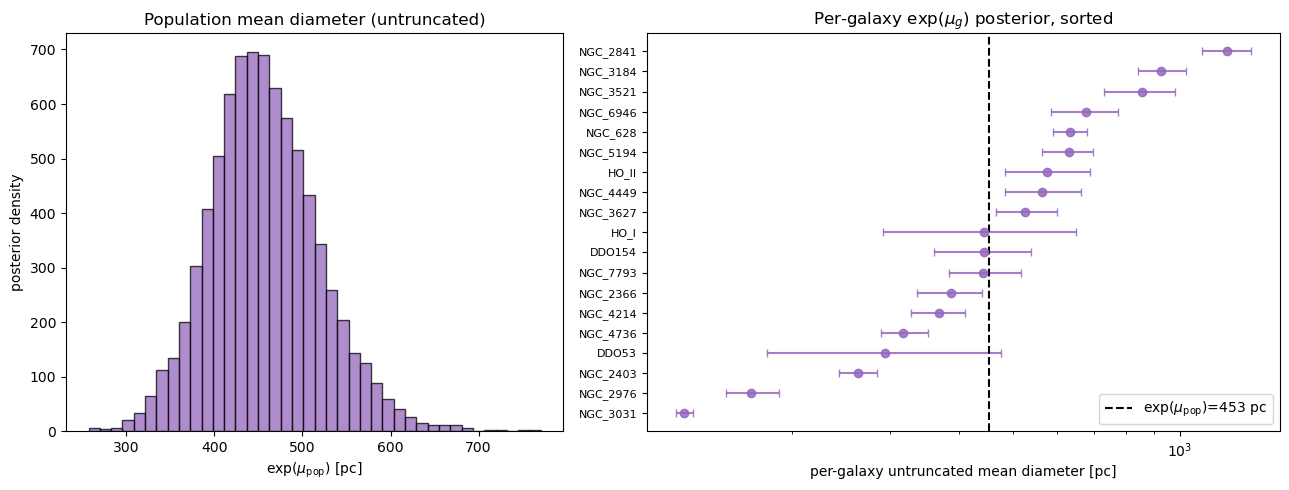

In [11]:
mu_g = az.summary(idata2, var_names=['mu_g'], hdi_prob=0.95).copy()
mu_g.index = [str(i).replace('mu_g[', '').rstrip(']') for i in mu_g.index]
mu_g = mu_g.sort_values('mean')
mu_pop_mean = float(idata2.posterior['mu_pop'].mean().item())

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [1.1, 1.4]})
axes[0].hist(np.exp(idata2.posterior['mu_pop'].values.flatten()), bins=40,
             color='tab:purple', alpha=0.75, edgecolor='k')
axes[0].set_xlabel(r'$\exp(\mu_{\rm pop})$ [pc]')
axes[0].set_ylabel('posterior density')
axes[0].set_title(rf'Population mean diameter (untruncated)')

y = np.arange(len(mu_g))
axes[1].errorbar(
    np.exp(mu_g['mean']), y,
    xerr=[np.exp(mu_g['mean']) - np.exp(mu_g['hdi_2.5%']),
          np.exp(mu_g['hdi_97.5%']) - np.exp(mu_g['mean'])],
    fmt='o', color='tab:purple', ecolor='tab:purple', alpha=0.85, capsize=3,
)
axes[1].axvline(np.exp(mu_pop_mean), color='k', ls='--',
                label=rf'$\exp(\mu_{{\rm pop}})$={np.exp(mu_pop_mean):.0f} pc')
axes[1].set_xscale('log')
axes[1].set_yticks(y)
axes[1].set_yticklabels(mu_g.index, fontsize=8)
axes[1].set_xlabel('per-galaxy untruncated mean diameter [pc]')
axes[1].set_title(r'Per-galaxy $\exp(\mu_g)$ posterior, sorted')
axes[1].legend(loc='lower right')
fig.tight_layout()

tau_mu = float(idata2.posterior['mu_pop'].std().item())  # naive
tau_mu_post = float(idata2.posterior['tau_mu'].mean().item())
print(f'Cross-galaxy heterogeneity tau_mu posterior mean = {tau_mu_post:.2f}')
print(f'  -> 1-sigma band on exp(mu_g) spans {np.exp(mu_pop_mean - tau_mu_post):.0f}-{np.exp(mu_pop_mean + tau_mu_post):.0f} pc')

### Model 3, Bayesian Chevalier-style energy regression

For type-{2,3} holes (where `vexp_kms` is measured):

\[
\log E_{43} = \alpha + \alpha_g + \beta\,\log d_{\rm pc} + \gamma\,\log v_{\rm exp} + \varepsilon
\]

Priors: `alpha ~ N(0, 5)`, `beta ~ N(2, 1)`, `gamma ~ N(2, 1)`,
`tau_galaxy ~ HN(0.5)`, `alpha_g ~ N(0, tau_galaxy)`,
`sigma ~ HN(1)`. The `Normal(2, 1)` priors on `(beta, gamma)` are the
Chevalier 1974 expectation `E ∝ R²V²ρ`. The B11 catalog computes
`log_E_J43` from `(diameter, vexp)` already, so the model is largely a
*self-consistency* check; a clean posterior predictive on
`log_E_J43` is the canonical sanity test for
[`hishells.catalog`](../hishells/catalog.py) parsing (plan §11
step 6). Posteriors of `(beta, gamma)` significantly off the
Chevalier priors mean B11 used a different scaling, *not* that the
parser is broken.

In [12]:
key3 = hash_dataframe(
    logo_holes[['galaxy_id', 'hole_type', 'diameter_pc', 'vexp_kms', 'log_E_J43']],
    DRAWS, SEED, tuple(LOGO_GALAXIES_19),
)
idata3 = cached_fit(
    CACHE_DIR, 'chevalier', key3,
    lambda: fit_chevalier(logo_holes, galaxy_ids=LOGO_GALAXIES_19, draws=DRAWS, seed=SEED),
)
az.summary(idata3, var_names=['alpha', 'beta', 'gamma', 'sigma', 'tau_galaxy']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-7.404,0.340,-8.046,-6.768,0.006,0.004,3365.0,3552.0,1.0
beta,1.267,0.055,1.160,1.368,0.001,0.001,3788.0,3503.0,1.0
gamma,0.769,0.053,0.668,0.867,0.001,0.001,7015.0,5629.0,1.0
sigma,0.309,0.011,0.289,0.330,0.000,0.000,7928.0,5674.0,1.0
tau_galaxy,0.280,0.061,0.174,0.394,0.001,0.001,5122.0,5195.0,1.0


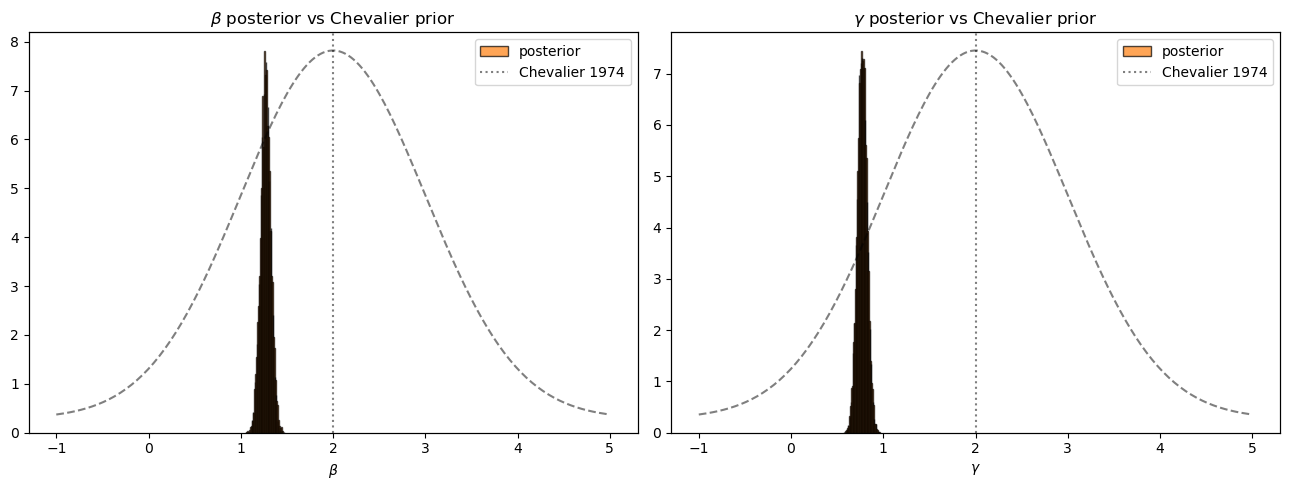

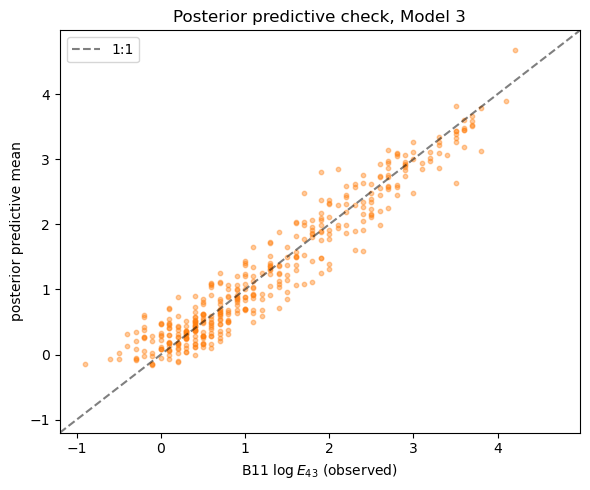

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
beta = idata3.posterior['beta'].values.flatten()
gamma = idata3.posterior['gamma'].values.flatten()
prior_x = np.linspace(-1, 5, 200)
prior_pdf = np.exp(-0.5 * (prior_x - 2.0) ** 2)  # unnormalised N(2,1) shape
prior_pdf /= prior_pdf.max()

for ax, samples, name in zip(axes, [beta, gamma], [r'$\beta$', r'$\gamma$']):
    ax.hist(samples, bins=60, density=True, alpha=0.7, color='tab:orange',
            edgecolor='k', label='posterior')
    ax2 = ax.twinx()
    ax2.plot(prior_x, prior_pdf, 'k--', alpha=0.5, label=r'prior $\mathcal{N}(2,1)$')
    ax2.set_yticks([])
    ax.axvline(2.0, color='k', ls=':', alpha=0.5, label='Chevalier 1974')
    ax.set_xlabel(name)
    ax.set_title(f'{name} posterior vs Chevalier prior')
    ax.legend(loc='upper right')
fig.tight_layout()

ppc = idata3.posterior_predictive['log_E']
obs = idata3.observed_data['log_E']
ppc_mean = ppc.mean(dim=('chain', 'draw')).values
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(obs.values, ppc_mean, s=10, alpha=0.4, color='tab:orange')
lim = (min(obs.min(), ppc_mean.min()) - 0.3, max(obs.max(), ppc_mean.max()) + 0.3)
ax.plot(lim, lim, 'k--', alpha=0.5, label='1:1')
ax.set_xlabel(r'B11 $\log E_{43}$ (observed)')
ax.set_ylabel('posterior predictive mean')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_title('Posterior predictive check, Model 3')
ax.legend()
fig.tight_layout()

### Model 4, Negative-Binomial GLM of per-galaxy hole counts

\[
\log \mu_g = \beta_0 + \beta_{\rm SFR}\,z_{{\rm SFR},g} + \beta_{\rm MHI}\,z_{{\rm MHI},g} + \beta_D\,z_{D,g}
\]
\[
n_g \sim \text{NegBinomial}(\mu_g, \alpha_{\rm nb})
\]

Predictors are z-scored across the 19 LOGO galaxies so the
`Normal(0, 1)` slope priors are scale-free. `alpha_nb ~ Exp(1)` is the
NB dispersion. The `log_likelihood` group is included so we can run
PSIS-LOO and flag galaxies whose count is anomalous given their global
properties (those with Pareto-k > 0.7 are the same anomalous-fold
candidates §6 calls out).

In [14]:
key4 = hash_dataframe(
    logo_holes[['galaxy_id']],
    logo_galaxies[['galaxy_id', 'log_sfr', 'MHI_1e8Msun', 'distance_mpc']],
    DRAWS, SEED, tuple(LOGO_GALAXIES_19),
)
idata4 = cached_fit(
    CACHE_DIR, 'count_rate', key4,
    lambda: fit_count_rate(
        logo_holes, logo_galaxies, galaxy_ids=LOGO_GALAXIES_19,
        draws=DRAWS, seed=SEED,
    ),
)
az.summary(idata4, var_names=['beta_0', 'beta_SFR', 'beta_MHI', 'beta_D', 'alpha_nb']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,3.510,0.160,3.219,3.821,0.002,0.002,7070.0,5183.0,1.0
beta_SFR,0.425,0.251,-0.018,0.928,0.004,0.003,4992.0,4692.0,1.0
beta_MHI,0.920,0.252,0.451,1.405,0.003,0.003,5235.0,5702.0,1.0
beta_D,-0.830,0.190,-1.189,-0.473,0.003,0.003,5521.0,4594.0,1.0
alpha_nb,2.689,0.905,1.064,4.323,0.012,0.012,5713.0,5333.0,1.0


Computed from 8000 posterior samples and 19 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -83.70     5.19
p_loo        2.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       19  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

galaxies flagged as Pareto-k > 0.7 outliers: []


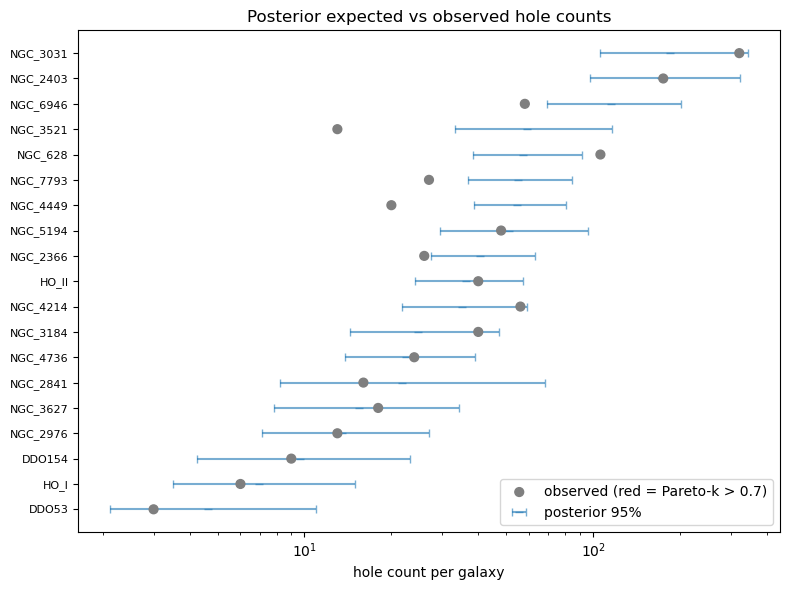

In [15]:
loo4 = az.loo(idata4, pointwise=True)
print(loo4)

mu_post = idata4.posterior['mu']
mu_q = mu_post.quantile([0.025, 0.5, 0.975], dim=('chain', 'draw'))
gal_coords = list(idata4.posterior['galaxy'].values)
n_obs = idata4.observed_data['n_holes'].values
pareto_k = loo4.pareto_k.values

fig, ax = plt.subplots(figsize=(8, 6))
order = np.argsort(mu_q.sel(quantile=0.5).values)
y = np.arange(len(order))
xs = mu_q.sel(quantile=0.5).values[order]
xs_lo = mu_q.sel(quantile=0.025).values[order]
xs_hi = mu_q.sel(quantile=0.975).values[order]
colors = ['tab:red' if k > 0.7 else 'tab:gray' for k in pareto_k[order]]

ax.errorbar(xs, y, xerr=[xs - xs_lo, xs_hi - xs],
            fmt='_', color='tab:blue', alpha=0.6, capsize=3, label='posterior 95%')
ax.scatter(n_obs[order], y, c=colors, s=40, zorder=3,
           label='observed (red = Pareto-k > 0.7)')
ax.set_yticks(y)
ax.set_yticklabels([gal_coords[i] for i in order], fontsize=8)
ax.set_xlabel('hole count per galaxy')
ax.set_xscale('log')
ax.set_title('Posterior expected vs observed hole counts')
ax.legend(loc='lower right')
fig.tight_layout()

flagged = [gal_coords[i] for i, k in enumerate(pareto_k) if k > 0.7]
print(f'galaxies flagged as Pareto-k > 0.7 outliers: {flagged}')

### Model 5, BEST axial-ratio comparison across hole types

Kruschke (2013) BEST: axial ratios within each hole type follow a
Student-t with shared degrees of freedom (`nu - 1 ~ Exp(1/29)`) and
type-specific `mu_t, sigma_t`. The deterministics
`diff_3_2 = mu_3 - mu_2`, etc. give pairwise mean differences with
direct posterior credible intervals. Closes the §2.4 corollary
question: *if* type-3 holes really are more circular (and thus the
"textbook ellipse" signature is a real diagnostic), the
`diff_3_2` and `diff_3_1` posteriors should sit clearly above zero.

In [16]:
key5 = hash_dataframe(
    logo_holes[['axial_ratio', 'hole_type']],
    DRAWS, SEED, tuple(LOGO_GALAXIES_19),
)
idata5 = cached_fit(
    CACHE_DIR, 'axial_best', key5,
    lambda: fit_axial_best(logo_holes, draws=DRAWS, seed=SEED),
)
az.summary(idata5, var_names=['mu_t', 'sigma_t', 'nu', 'diff_3_2', 'diff_3_1', 'diff_2_1']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_t[1],0.719,0.006,0.707,0.731,0.000,0.000,12713.0,6253.0,1.0
mu_t[2],0.736,0.010,0.716,0.754,0.000,0.000,12186.0,6562.0,1.0
mu_t[3],0.773,0.014,0.747,0.798,0.000,0.000,12114.0,6610.0,1.0
sigma_t[1],0.155,0.005,0.146,0.163,0.000,0.000,11495.0,5617.0,1.0
sigma_t[2],0.164,0.007,0.150,0.178,0.000,0.000,11501.0,6028.0,1.0
sigma_t[3],0.170,0.010,0.152,0.190,0.000,0.000,12920.0,6340.0,1.0
nu,91.763,40.717,29.949,165.654,0.398,0.603,11829.0,5999.0,1.0
diff_3_2,0.038,0.017,0.007,0.071,0.000,0.000,11827.0,6257.0,1.0
diff_3_1,0.055,0.015,0.027,0.084,0.000,0.000,12824.0,6475.0,1.0
diff_2_1,0.017,0.012,-0.006,0.039,0.000,0.000,11609.0,6281.0,1.0


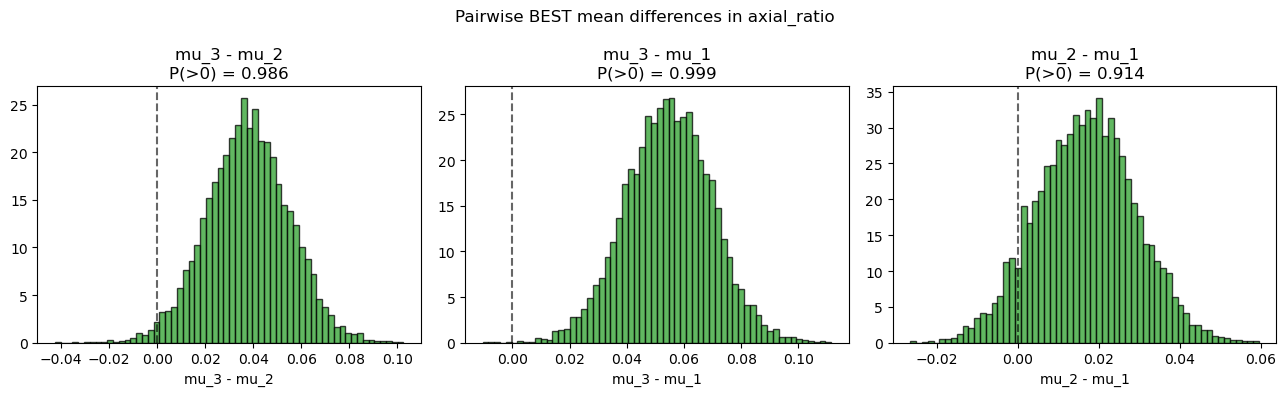

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
diffs = [
    ('diff_3_2', 'mu_3 - mu_2'),
    ('diff_3_1', 'mu_3 - mu_1'),
    ('diff_2_1', 'mu_2 - mu_1'),
]
for ax, (var, label) in zip(axes, diffs):
    samples = idata5.posterior[var].values.flatten()
    ax.hist(samples, bins=60, density=True, alpha=0.75,
            color='tab:green', edgecolor='k')
    ax.axvline(0, color='k', ls='--', alpha=0.6)
    p_gt_zero = float((samples > 0).mean())
    ax.set_xlabel(label)
    ax.set_title(f'{label}\nP(>0) = {p_gt_zero:.3f}')
fig.suptitle('Pairwise BEST mean differences in axial_ratio')
fig.tight_layout()

In [18]:
verdict_rows = []

# Model 1, type fractions: how many galaxies have pi_23 lower bound below 0.4?
pi23_summary = az.summary(idata1, var_names=['pi_23'], hdi_prob=0.95)
n_starved = int((pi23_summary['hdi_2.5%'] < 0.4).sum())
n_total = len(pi23_summary)
verdict_rows.append({
    'plan_section': '§2.4 type filter',
    'model': 'Model 1 (Dirichlet-Multinomial)',
    'verdict': f'{n_starved}/{n_total} galaxies have a 95% lower bound on π_(2,3) < 0.4',
    'action': 'keep §2.4 default {2,3}' if n_starved <= 3
             else 'reconsider §2.4 default; consider {1,2,3} for at-risk folds',
})

# Model 2, cross-galaxy heterogeneity in size law
tau_mu_post = float(idata2.posterior['tau_mu'].mean().item())
verdict_rows.append({
    'plan_section': '§6 LOGO heterogeneity',
    'model': 'Model 2 (truncated lognormal)',
    'verdict': f'tau_mu posterior mean = {tau_mu_post:.2f} (1-sigma factor of {np.exp(tau_mu_post):.1f}x in mean diameter)',
    'action': 'expect non-trivial cross-galaxy gap in LOGO; per-galaxy normalisation in §6 is justified',
})

# Model 3, Chevalier slopes vs prior
beta_post = float(idata3.posterior['beta'].mean().item())
gamma_post = float(idata3.posterior['gamma'].mean().item())
ppc_mean = idata3.posterior_predictive['log_E'].mean(dim=('chain', 'draw')).values
obs_E = idata3.observed_data['log_E'].values
ppc_corr = float(np.corrcoef(ppc_mean, obs_E)[0, 1])
verdict_rows.append({
    'plan_section': '§11 step 6 catalog parsing',
    'model': 'Model 3 (Chevalier regression)',
    'verdict': f'beta={beta_post:.2f}, gamma={gamma_post:.2f}; PPC vs observed corr = {ppc_corr:.3f}',
    'action': ('hishells.catalog parsing internally consistent'
               if ppc_corr > 0.9 else 'check log_E_J43 column units / scaling in catalog.py'),
})

# Model 4, anomalous galaxies
loo4_k = az.loo(idata4, pointwise=True).pareto_k.values
flagged = [list(idata4.posterior['galaxy'].values)[i] for i, k in enumerate(loo4_k) if k > 0.7]
verdict_rows.append({
    'plan_section': '§6 anomalous-fold callouts',
    'model': 'Model 4 (NB count rate)',
    'verdict': f'{len(flagged)} galaxies with Pareto-k > 0.7: {flagged}',
    'action': 'pre-flag these folds in §6.1 results table' if flagged else 'no LOGO anomalies',
})

# Model 5, axial-ratio differences
d32 = idata5.posterior['diff_3_2'].values.flatten()
d31 = idata5.posterior['diff_3_1'].values.flatten()
p32 = float((d32 > 0).mean())
p31 = float((d31 > 0).mean())
verdict_rows.append({
    'plan_section': '§2.4 corollary (type-3 ellipse)',
    'model': 'Model 5 (BEST)',
    'verdict': f'P(mu_3 > mu_2) = {p32:.2f}; P(mu_3 > mu_1) = {p31:.2f}',
    'action': ('axial_ratio supports type-3 distinctness' if p32 > 0.95 and p31 > 0.95
               else 'axial_ratio does NOT robustly distinguish type-3'),
})

verdict_df = pd.DataFrame(verdict_rows)[['plan_section', 'model', 'verdict', 'action']]

with pd.option_context('display.max_colwidth', 120, 'display.width', 220):
    print(verdict_df.to_string(index=False))

verdict_df

                   plan_section                           model                                                                verdict                                                                                   action
               §2.4 type filter Model 1 (Dirichlet-Multinomial)                 18/19 galaxies have a 95% lower bound on π_(2,3) < 0.4                              reconsider §2.4 default; consider {1,2,3} for at-risk folds
          §6 LOGO heterogeneity   Model 2 (truncated lognormal) tau_mu posterior mean = 0.60 (1-sigma factor of 1.8x in mean diameter) expect non-trivial cross-galaxy gap in LOGO; per-galaxy normalisation in §6 is justified
     §11 step 6 catalog parsing  Model 3 (Chevalier regression)                    beta=1.27, gamma=0.77; PPC vs observed corr = 0.961                                           hishells.catalog parsing internally consistent
     §6 anomalous-fold callouts         Model 4 (NB count rate)                                     0 ga

,plan_section,model,verdict,action
0,§2.4 type filter,Model 1 (Dirichlet-Multinomial),"18/19 galaxies have a 95% lower bound on π_(2,...","reconsider §2.4 default; consider {1,2,3} for ..."
1,§6 LOGO heterogeneity,Model 2 (truncated lognormal),tau_mu posterior mean = 0.60 (1-sigma factor o...,expect non-trivial cross-galaxy gap in LOGO; p...
2,§11 step 6 catalog parsing,Model 3 (Chevalier regression),"beta=1.27, gamma=0.77; PPC vs observed corr = ...",hishells.catalog parsing internally consistent
3,§6 anomalous-fold callouts,Model 4 (NB count rate),0 galaxies with Pareto-k > 0.7: [],no LOGO anomalies
4,§2.4 corollary (type-3 ellipse),Model 5 (BEST),P(mu_3 > mu_2) = 0.99; P(mu_3 > mu_1) = 1.00,axial_ratio supports type-3 distinctness


### What this section locks (Bayesian)

The verdict table above is the row-level output of this notebook.
Sampler diagnostics (R-hat ≤ 1.01 and ESS ≥ 400 for all "global"
parameters) are visible in the per-model `az.summary` cells above; if
any parameter regresses, the cached NetCDF traces under
[`HIShells/results/bayes/`](../results/bayes/) carry the full chains
for offline diagnosis.

What the five models concretely change in `plan.md`:

- **§2.4 type filter** — Model 1 quantifies how many LOGO folds are
  starved by the type-{2,3} default. If the verdict table flags ≥ 4
  galaxies, the `--hole-types {1,2,3}` ablation in §9 Row 10 should
  precede the v1 baseline rather than follow it.
- **§6 LOGO heterogeneity** — Model 2's posterior `tau_mu` measures
  cross-galaxy heterogeneity in the *true* hole-size law. A 1σ band
  spanning more than ~2× in mean diameter justifies the per-cube
  normalisation choice already in §2.1.
- **§11 step 6 sanity** — Model 3's posterior predictive on
  `log_E_J43` is the canonical parser-correctness check; if PPC vs
  observed correlation < 0.9, halt and audit
  [`hishells.catalog`](../hishells/catalog.py) before any model
  training.
- **§6 anomalous folds** — Model 4 names the Pareto-k > 0.7 galaxies;
  these are the pre-flagged candidates for "anomalously low scores"
  in §6.1's CSV `notes` column.
- **§2.4 corollary** — Model 5 says whether type-3 holes really are
  more circular in the catalog. If `P(mu_3 > mu_2) < 0.95`, soften
  the §2.4 claim that "type-3 has the diagnostic ellipse signature"
  in any §9 reporting.

Re-running this notebook on cached traces is < 1s; full re-fit on
~1k holes / 19 galaxies is ≈ 4 min on CPU.